In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
from collections import Counter
import matplotlib.pyplot as plt

/home/soham/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
# -------------------------
# 1. Count images by label
# -------------------------
def count_images(root="Main"):
    labels = ["Negative", "Neutral", "Positive"]
    total_counts = Counter()

    for split in ["Train", "Test", "Val"]:
        for label in labels:
            folder = os.path.join(root, split, label)
            if os.path.isdir(folder):
                if "JPG" in folder:
                    print("JPG is there!")
                total_counts[label] += len([
                    f for f in os.listdir(folder)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))
                ])
    
    return total_counts

In [4]:
# Run counting
root = "/kaggle/input/docimsent/Dataset/Main"
counts = count_images(root)
print("Image Distribution:", counts)

Image Distribution: Counter()


In [5]:
# -------------- out of 2875 images ----------------------------
# \textit{\textcolor[HTML]{}{Negative}}: 31.5\% (646 instances)
# \textit{\textcolor[HTML]{}{Neutral}}: 31.9\% (656 instances)
# \textit{\textcolor[HTML]{}{Positive}}: 36.6\% (752 instances)

# -------------- out of 1711 images ----------------------------
# \textit{\textcolor[HTML]{}{Negative}}: ??.?\% (522 instances)
# \textit{\textcolor[HTML]{}{Neutral}}: ??.?\% (562 instances)
# \textit{\textcolor[HTML]{}{Positive}}: ??.?\% (627 instances)


green = "d62728"
yellow = "febb78"
red = "2ca02c"

In [6]:
# -------------------------
# 2. Plot a hollow pie chart
# -------------------------
labels = list(counts.keys())
sizes = list(counts.values())

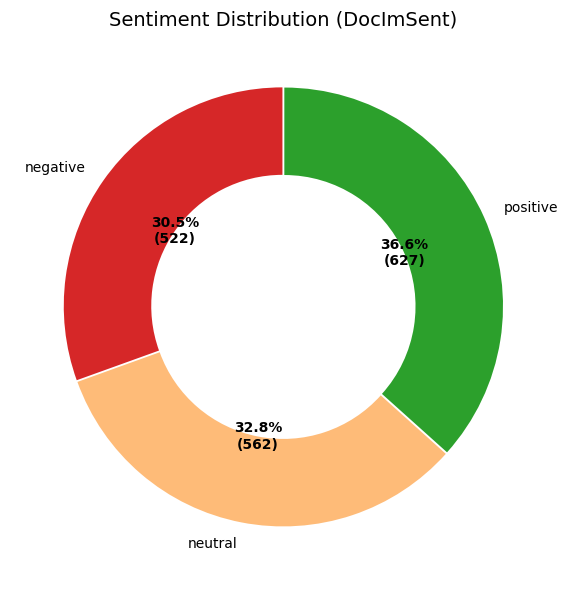

In [7]:
import matplotlib.pyplot as plt

# lowercase labels
labels = [lbl.lower() for lbl in labels]

# Your custom colors
colors = ["#d62728", "#febb78", "#2ca02c"]   # red, yellow, green

# Function to format labels with pct + count in bold
def make_autopct(values):
    def autopct_format(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({count})"
    return autopct_format

plt.figure(figsize=(6,6))

explode = [0.005, 0.005, 0.005]   # small gap between slices

wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    startangle=90,
    wedgeprops=dict(width=0.4),
    autopct=make_autopct(sizes),
    textprops={'fontsize': 10}
)

# Make autopct text bold as well
for autotext in autotexts:
    autotext.set_fontweight('bold')

plt.title("Sentiment Distribution (DocImSent)", fontsize=14)
plt.tight_layout()
plt.savefig('DocImSent__classDist_1711.png')
plt.show()